# 02 - Inteligência de Priorizaçã

**Objetivo:** transformar as análises da Parte 1 em uma regra de negócio que escolha automaticamente os **2 melhores telefones por CPF**.

## Decisão de modelagem

O alvo do modelo passa a ser **entrega** (`delivered` ou `read`), porque a decisão operacional do motor é escolher números com maior chance de estar ativos. A taxa de `read` continua sendo acompanhada como metrica de negocio e como criterio do experimento A/B.


### 1. Imports e Configuração

In [25]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportion_confint

import utils as u

SEED = 42
HALF_LIFE_GRID = [30, 60, 90, 120, 180, 270, 365]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK.')


Imports OK.


---
## 2. Carregamento, Estruturação e Split Temporal

O notebook trabalha com duas entidades diferentes:

1. **Evento observado**: um disparo histórico para um telefone, com seu `status_disparo`
2. **Telefone candidato**: um número que pode ser escolhido para um CPF

O split temporal é feito logo no inicio. Tudo que vira prior ou score usado na validação é aprendido **apenas no período de treino**.


### 2.1 Carregar Dados Brutos e Preparar Bases

In [ ]:

df_disparo, df_telefone = u.carregar_dados()

df_disparo = u.filtrar_status_invalidos(df_disparo)
df_telefone = u.filtrar_telefones_fixos(df_telefone)

df_disparo['envio_datahora'] = pd.to_datetime(df_disparo['envio_datahora'])
df_disparo = df_disparo.sort_values('envio_datahora').reset_index(drop=True)


def extrair_cpfs(aparicoes):
    if isinstance(aparicoes, (list, np.ndarray)):
        cpfs = [item.get('cpf') for item in aparicoes if item.get('cpf') is not None]
        return sorted(set(cpfs))
    return []


df_aparicoes = u.explodir_aparicoes(df_telefone)
df_aparicoes = df_aparicoes.drop_duplicates().copy()
df_aparicoes['registro_data_atualizacao'] = pd.to_datetime(
    df_aparicoes['registro_data_atualizacao'],
    errors='coerce',
)

# Metadados estaticos do telefone
df_phone_meta = df_telefone[['telefone_numero', 'telefone_ddd', 'telefone_proprietarios_quantidade']].copy()
df_phone_meta = df_phone_meta.rename(columns={'telefone_proprietarios_quantidade': 'n_proprietarios'})
df_phone_meta['n_proprietarios'] = df_phone_meta['n_proprietarios'].fillna(1).clip(lower=1)
df_phone_meta['penalidade_proprietarios'] = 1 / df_phone_meta['n_proprietarios']
df_phone_meta['cpfs'] = df_telefone['telefone_aparicoes'].apply(extrair_cpfs)

df_n_sistemas = (
    df_aparicoes.groupby('telefone_numero')['id_sistema']
    .nunique()
    .reset_index(name='n_sistemas_telefone')
)
df_phone_meta = df_phone_meta.merge(df_n_sistemas, on='telefone_numero', how='left')
df_phone_meta['n_sistemas_telefone'] = df_phone_meta['n_sistemas_telefone'].fillna(0).astype(int)

# Split temporal
cutoff_idx = int(len(df_disparo) * 0.8)
cutoff_time = df_disparo.loc[cutoff_idx, 'envio_datahora']

df_train_disparo = df_disparo[df_disparo['envio_datahora'] < cutoff_time].copy()
df_val_disparo = df_disparo[df_disparo['envio_datahora'] >= cutoff_time].copy()

print('Disparos validos:', df_disparo.shape)
print('Telefones validos:', df_telefone.shape)
print('Periodo observado:', df_disparo['envio_datahora'].min(), '->', df_disparo['envio_datahora'].max())
print('Cutoff temporal:', cutoff_time)
print('Treino:', len(df_train_disparo))
print('Validacao:', len(df_val_disparo))


Filtrando status=processing: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,289 (-0)
Telefones únicos: 283,289
Linhas após explosão: 1,529,772
Sistemas únicos: 6
Disparos validos: (389761, 16)
Telefones validos: (283289, 11)
Periodo observado: 2025-09-03 09:43:05 -> 2026-04-18 14:28:19
Cutoff temporal: 2026-03-24 09:29:19.878000
Treino: 311808
Validacao: 77953


---
## 3. Ranking de Sistemas com Ajuste de Vies

Em vez de usar apenas o `wilson_lower_read` geral, o score de origem passa a combinar três sinais aprendidos no **treino**:

- `wilson_lower_read`: robustez no histórico agregado
- `wilson_first_touch`: desempenho quando o telefone aparece pela primeira vez
- `taxa_vitoria`: frequência com que o sistema é o melhor dentro do mesmo CPF

O score final do sistema fica:

`0.30 * score_geral + 0.60 * score_first_touch + 0.10 * score_vitoria`

Damos mais peso ao **first-touch** porque ele sofre menos com reutilização de números já conhecidos como bons.


### 3.1 Funções Auxiliares de Score por Sistema

=== RANKING DE SISTEMAS APRENDIDO NO TREINO ===


,id_sistema,total_disparos,wilson_lower_read,wilson_first_touch,taxa_vitoria,score_sistema_ajustado
0,-4704067261970591609,186292,0.777344,0.788615,0.797970,0.982653
1,3094574413675758272,486386,0.740471,0.751830,0.025041,0.743341
2,-2757366171786647144,5282,0.688763,0.673635,0.752968,0.519459
3,4458959843028638627,20770,0.681725,0.684906,0.008326,0.464856
4,1257277410380486863,216220,0.642536,0.628014,0.444529,0.290035
5,-133612832286195827,470650,0.559032,0.583755,0.963697,0.100000


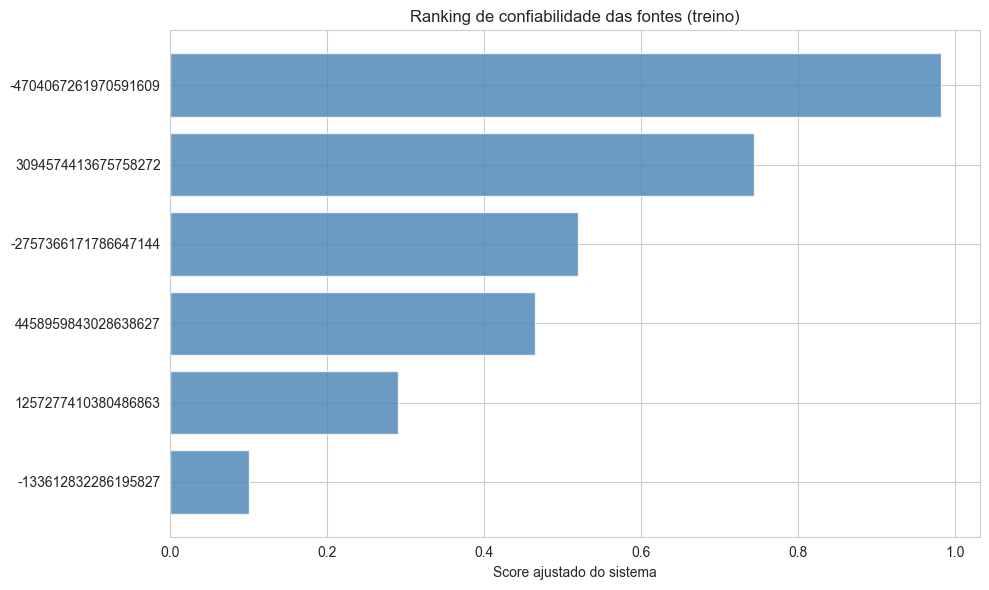

In [ ]:
def wilson_lower_bound(successes, total, alpha=0.05):
    if total == 0:
        return 0.0
    return proportion_confint(successes, total, alpha=alpha, method='wilson')[0]


def normalizar_0_1(series):
    series = series.astype(float)
    if series.nunique(dropna=True) <= 1:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())


def calcular_metricas_sistema(df_base):
    metricas = (
        df_base.groupby('id_sistema')
        .agg(
            total_disparos=('id_disparo', 'count'),
            read=('status_disparo', lambda x: (x == 'read').sum()),
            delivered=('status_disparo', lambda x: (x == 'delivered').sum()),
            failed=('status_disparo', lambda x: (x == 'failed').sum()),
        )
        .reset_index()
    )
    metricas['taxa_leitura'] = metricas['read'] / metricas['total_disparos']
    metricas['taxa_entrega'] = (metricas['read'] + metricas['delivered']) / metricas['total_disparos']
    metricas['wilson_lower_read'] = metricas.apply(
        lambda row: wilson_lower_bound(row['read'], row['total_disparos']),
        axis=1,
    )
    return metricas


def calcular_score_sistema_ajustado(df_disparo_periodo, df_aparicoes_periodo):
    df_join = df_disparo_periodo.merge(
        df_aparicoes_periodo,
        left_on='contato_telefone',
        right_on='telefone_numero',
        how='inner',
    ).copy()

    geral = calcular_metricas_sistema(df_join)

    first_touch_disparo = (
        df_disparo_periodo.sort_values('envio_datahora')
        .drop_duplicates(subset='contato_telefone', keep='first')
    )
    first_touch_join = first_touch_disparo.merge(
        df_aparicoes_periodo,
        left_on='contato_telefone',
        right_on='telefone_numero',
        how='inner',
    )
    first_touch = calcular_metricas_sistema(first_touch_join)[['id_sistema', 'wilson_lower_read']]
    first_touch = first_touch.rename(columns={'wilson_lower_read': 'wilson_first_touch'})

    cpf_sistema = (
        df_join.groupby(['cpf_sistema', 'id_sistema'])
        .agg(
            total=('id_disparo', 'count'),
            read=('status_disparo', lambda x: (x == 'read').sum()),
        )
        .reset_index()
    )
    cpf_sistema = cpf_sistema[cpf_sistema['total'] > 0].copy()
    cpf_sistema['taxa_leitura'] = cpf_sistema['read'] / cpf_sistema['total']

    cpf_multi = (
        cpf_sistema.groupby('cpf_sistema')['id_sistema']
        .nunique()
        .loc[lambda s: s >= 2]
        .index
    )

    cpf_rank = cpf_sistema[cpf_sistema['cpf_sistema'].isin(cpf_multi)].copy()
    cpf_rank['rank_no_cpf'] = cpf_rank.groupby('cpf_sistema')['taxa_leitura'].rank(
        ascending=False,
        method='first',
    )

    vitorias = (
        cpf_rank[cpf_rank['rank_no_cpf'] == 1]
        .groupby('id_sistema')
        .size()
        .reset_index(name='vitorias')
    )
    participacoes = cpf_rank.groupby('id_sistema').size().reset_index(name='participacoes')

    vitorias = vitorias.merge(participacoes, on='id_sistema', how='outer').fillna(0)
    vitorias['taxa_vitoria'] = np.where(
        vitorias['participacoes'] > 0,
        vitorias['vitorias'] / vitorias['participacoes'],
        np.nan,
    )

    metricas = geral.merge(first_touch, on='id_sistema', how='left')
    metricas = metricas.merge(vitorias[['id_sistema', 'taxa_vitoria']], on='id_sistema', how='left')

    metricas['wilson_first_touch'] = metricas['wilson_first_touch'].fillna(metricas['wilson_lower_read'])
    metricas['taxa_vitoria'] = metricas['taxa_vitoria'].fillna(metricas['taxa_vitoria'].median())
    metricas['taxa_vitoria'] = metricas['taxa_vitoria'].fillna(0.0)

    metricas['score_geral_norm'] = normalizar_0_1(metricas['wilson_lower_read'])
    metricas['score_first_touch_norm'] = normalizar_0_1(metricas['wilson_first_touch'])
    metricas['score_vitoria_norm'] = normalizar_0_1(metricas['taxa_vitoria'])

    metricas['score_sistema_ajustado'] = (
        0.30 * metricas['score_geral_norm']
        + 0.60 * metricas['score_first_touch_norm']
        + 0.10 * metricas['score_vitoria_norm']
    )

    metricas = metricas.sort_values('score_sistema_ajustado', ascending=False).reset_index(drop=True)
    return metricas, df_join, first_touch, vitorias


metricas_sistema_train, df_train_sistema, metricas_first_touch_train, vitorias_train = (
    calcular_score_sistema_ajustado(df_train_disparo, df_aparicoes)
)

print('=== RANKING DE SISTEMAS APRENDIDO NO TREINO ===')
display(
    metricas_sistema_train[
        ['id_sistema', 'total_disparos', 'wilson_lower_read', 'wilson_first_touch', 'taxa_vitoria', 'score_sistema_ajustado']
    ]
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = metricas_sistema_train.sort_values('score_sistema_ajustado')
ax.barh(plot_df['id_sistema'].astype(str), plot_df['score_sistema_ajustado'], color='steelblue', alpha=0.8)
ax.set_xlabel('Score ajustado do sistema')
ax.set_title('Ranking de confiabilidade das fontes (treino)')
plt.tight_layout()
plt.show()


---
## 4. Base Causal de Eventos e Grid Search do Half-life

A recencia é calculada **por evento**:

`dias_desde_atualizacao = envio_datahora - registro_data_atualizacao`

Se a `registro_data_atualizacao` estiver no futuro em relação ao disparo, o valor é tratado como **não causal** e recebe penalizacao máxima. Assim evitamos usar informação que ainda não existia no momento da decisão.

O score de aparição fica:

`score_aparicao_causal = score_sistema_ajustado * decaimento_temporal`

Depois agregamos cada disparo para uma linha por telefone observado e treinamos a regressão logística.


### 4.1 Base, Prior de DDD e Grid Search

=== GRID SEARCH DO HALF-LIFE ===


,half_life,auc_entrega,log_loss_entrega,brier_entrega,rank_auc,rank_log_loss,rank_brier,rank_medio
1,60,0.649713,0.262489,0.067723,1.0,2.0,2.0,1.666667
0,30,0.647145,0.237806,0.061044,5.0,1.0,1.0,2.333333
2,90,0.649177,0.270985,0.070406,3.0,3.0,3.0,3.000000
3,120,0.648249,0.275039,0.071843,4.0,4.0,4.0,4.000000
6,365,0.649231,0.276584,0.073522,2.0,5.0,6.0,4.333333
4,180,0.646002,0.278130,0.073255,7.0,6.0,5.0,6.000000
5,270,0.647006,0.278305,0.073749,6.0,7.0,7.0,6.666667


Half-life escolhido: 60 dias


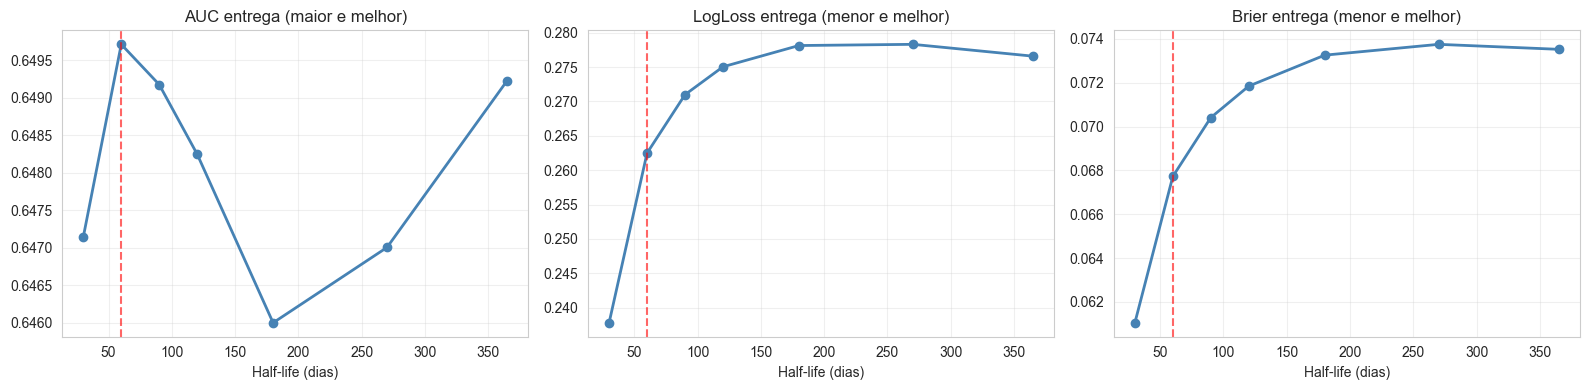

In [ ]:
df_aparicoes_train_score = df_aparicoes.merge(
    metricas_sistema_train[['id_sistema', 'score_sistema_ajustado']],
    on='id_sistema',
    how='left',
)
fallback_system_score = metricas_sistema_train['score_sistema_ajustado'].min()
df_aparicoes_train_score['score_sistema_ajustado'] = df_aparicoes_train_score['score_sistema_ajustado'].fillna(fallback_system_score)

df_evento_aparicao = (
    df_disparo.merge(
        df_aparicoes_train_score[
            ['telefone_numero', 'id_sistema', 'cpf_sistema', 'registro_data_atualizacao', 'score_sistema_ajustado']
        ],
        left_on='contato_telefone',
        right_on='telefone_numero',
        how='inner',
    )
    .merge(
        df_phone_meta[['telefone_numero', 'telefone_ddd', 'n_proprietarios', 'penalidade_proprietarios', 'n_sistemas_telefone']],
        on='telefone_numero',
        how='left',
    )
)


def preparar_eventos_causais(df_evento_aparicao_base, half_life):
    df = df_evento_aparicao_base.copy()

    dias = (df['envio_datahora'] - df['registro_data_atualizacao']).dt.days
    df['tem_data_causal'] = df['registro_data_atualizacao'].notna() & dias.ge(0)
    df['dias_desde_atualizacao'] = np.where(df['tem_data_causal'], dias, 9999)
    df['decaimento_temporal'] = np.exp(-np.log(2) * df['dias_desde_atualizacao'] / half_life)
    df['score_aparicao_causal'] = df['score_sistema_ajustado'] * df['decaimento_temporal']

    eventos = (
        df.groupby(
            [
                'id_disparo',
                'contato_telefone',
                'envio_datahora',
                'status_disparo',
                'telefone_ddd',
                'n_proprietarios',
                'penalidade_proprietarios',
                'n_sistemas_telefone',
            ],
            as_index=False,
        )
        .agg(
            max_score_origem_tempo=('score_aparicao_causal', 'max'),
            melhor_score_sistema=('score_sistema_ajustado', 'max'),
            melhor_decaimento=('decaimento_temporal', 'max'),
            melhor_dias_atualizacao=('dias_desde_atualizacao', 'min'),
            proporcao_aparicoes_causais=('tem_data_causal', 'mean'),
            qtd_aparicoes=('id_sistema', 'size'),
        )
    )

    eventos['telefone_ddd'] = eventos['telefone_ddd'].fillna(-1)
    eventos['n_proprietarios'] = eventos['n_proprietarios'].fillna(1).clip(lower=1)
    eventos['penalidade_proprietarios'] = eventos['penalidade_proprietarios'].fillna(1.0)
    eventos['n_sistemas_telefone'] = eventos['n_sistemas_telefone'].fillna(0)
    eventos['log_n_sistemas_telefone'] = np.log1p(eventos['n_sistemas_telefone'])

    eventos['y_entrega'] = eventos['status_disparo'].isin(['delivered', 'read']).astype(int)
    eventos['y_read'] = (eventos['status_disparo'] == 'read').astype(int)
    return eventos


def calcular_prior_suavizado(df_train_base, grupo_col, target_col, alpha=50):
    baseline = df_train_base[target_col].mean()
    prior = (
        df_train_base.groupby(grupo_col)[target_col]
        .agg(['sum', 'count'])
        .reset_index()
    )
    prior['score_prior'] = (prior['sum'] + alpha * baseline) / (prior['count'] + alpha)
    return prior[[grupo_col, 'score_prior']], baseline


def preparar_matrizes_modelo(df_eventos, cutoff_time_ref):
    df_train_modelo = df_eventos[df_eventos['envio_datahora'] < cutoff_time_ref].copy()
    df_val_modelo = df_eventos[df_eventos['envio_datahora'] >= cutoff_time_ref].copy()

    prior_ddd, baseline_ddd = calcular_prior_suavizado(df_train_modelo, 'telefone_ddd', 'y_entrega')

    df_train_modelo = df_train_modelo.merge(prior_ddd, on='telefone_ddd', how='left').rename(columns={'score_prior': 'score_ddd'})
    df_val_modelo = df_val_modelo.merge(prior_ddd, on='telefone_ddd', how='left').rename(columns={'score_prior': 'score_ddd'})

    df_train_modelo['score_ddd'] = df_train_modelo['score_ddd'].fillna(baseline_ddd)
    df_val_modelo['score_ddd'] = df_val_modelo['score_ddd'].fillna(baseline_ddd)

    feature_cols = [
        'max_score_origem_tempo',
        'penalidade_proprietarios',
        'score_ddd',
        'log_n_sistemas_telefone',
        'proporcao_aparicoes_causais',
    ]
    return df_train_modelo, df_val_modelo, feature_cols, prior_ddd, baseline_ddd


resultados_grid = []

for half_life in HALF_LIFE_GRID:
    df_eventos_hl = preparar_eventos_causais(df_evento_aparicao, half_life)
    df_train_modelo, df_val_modelo, feature_cols, prior_ddd_hl, baseline_ddd_hl = preparar_matrizes_modelo(
        df_eventos_hl,
        cutoff_time,
    )

    X_train = df_train_modelo[feature_cols].fillna(0)
    X_val = df_val_modelo[feature_cols].fillna(0)
    y_train = df_train_modelo['y_entrega']
    y_val = df_val_modelo['y_entrega']

    scaler_hl = StandardScaler()
    X_train_s = scaler_hl.fit_transform(X_train)
    X_val_s = scaler_hl.transform(X_val)

    modelo_hl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
    modelo_hl.fit(X_train_s, y_train)

    y_proba_val = modelo_hl.predict_proba(X_val_s)[:, 1]

    resultados_grid.append({
        'half_life': half_life,
        'auc_entrega': roc_auc_score(y_val, y_proba_val),
        'log_loss_entrega': log_loss(y_val, y_proba_val),
        'brier_entrega': brier_score_loss(y_val, y_proba_val),
    })


df_grid = pd.DataFrame(resultados_grid)
df_grid['rank_auc'] = df_grid['auc_entrega'].rank(ascending=False)
df_grid['rank_log_loss'] = df_grid['log_loss_entrega'].rank(ascending=True)
df_grid['rank_brier'] = df_grid['brier_entrega'].rank(ascending=True)
df_grid['rank_medio'] = df_grid[['rank_auc', 'rank_log_loss', 'rank_brier']].mean(axis=1)

BEST_HALF_LIFE = int(df_grid.loc[df_grid['rank_medio'].idxmin(), 'half_life'])

print('=== GRID SEARCH DO HALF-LIFE ===')
display(df_grid.sort_values('rank_medio'))
print('Half-life escolhido:', BEST_HALF_LIFE, 'dias')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metricas_plot = [
    ('auc_entrega', 'AUC entrega (maior e melhor)'),
    ('log_loss_entrega', 'LogLoss entrega (menor e melhor)'),
    ('brier_entrega', 'Brier entrega (menor e melhor)'),
]

for ax, (col, titulo) in zip(axes, metricas_plot):
    ax.plot(df_grid['half_life'], df_grid[col], marker='o', color='steelblue', linewidth=2)
    ax.axvline(BEST_HALF_LIFE, color='red', linestyle='--', alpha=0.6)
    ax.set_title(titulo)
    ax.set_xlabel('Half-life (dias)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5. Modelo Final de Validação

Com o `half-life` escolhido, treinamos o modelo final no periodo de treino e avaliamos no periodo futuro.

As features finais são:

- `max_score_origem_tempo`: melhor combinação origem + recência no evento
- `penalidade_proprietarios`: reduz score de números muito compartilhados
- `score_ddd`: prior suavizado de entrega por DDD aprendido no treino
- `log_n_sistemas_telefone`: diversidade de fontes do numero
- `proporcao_aparicoes_causais`: quanto da informação do telefone era realmente causal


### 5.1 Treinar e Avaliar o Modelo FInal no HoldOut

In [ ]:
df_eventos_best = preparar_eventos_causais(df_evento_aparicao, BEST_HALF_LIFE)
df_train_modelo, df_val_modelo, feature_cols, prior_ddd_train, baseline_ddd_train = preparar_matrizes_modelo(
    df_eventos_best,
    cutoff_time,
)

X_train = df_train_modelo[feature_cols].fillna(0)
X_val = df_val_modelo[feature_cols].fillna(0)
y_train = df_train_modelo['y_entrega']
y_val = df_val_modelo['y_entrega']

scaler_validacao = StandardScaler()
X_train_s = scaler_validacao.fit_transform(X_train)
X_val_s = scaler_validacao.transform(X_val)

modelo_validacao = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
modelo_validacao.fit(X_train_s, y_train)

y_proba_val = modelo_validacao.predict_proba(X_val_s)[:, 1]
df_val_modelo['score_modelo_validacao'] = y_proba_val

metricas_validacao = {
    'auc_entrega': roc_auc_score(df_val_modelo['y_entrega'], y_proba_val),
    'log_loss_entrega': log_loss(df_val_modelo['y_entrega'], y_proba_val),
    'brier_entrega': brier_score_loss(df_val_modelo['y_entrega'], y_proba_val),
    'taxa_entrega_validacao': df_val_modelo['y_entrega'].mean(),
    'taxa_read_validacao': df_val_modelo['y_read'].mean(),
    'taxa_read_top_decile': (
        df_val_modelo.sort_values('score_modelo_validacao', ascending=False)
        .head(max(1, int(len(df_val_modelo) * 0.10)))['y_read']
        .mean()
    ),
}

print('=== METRICAS DE VALIDACAO TEMPORAL ===')
for chave, valor in metricas_validacao.items():
    print(f'{chave}: {valor:.4f}')

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef_padronizado': modelo_validacao.coef_[0],
}).sort_values('coef_padronizado', ascending=False)

print('\nCoeficientes padronizados:')
display(coef_df)


=== METRICAS DE VALIDACAO TEMPORAL ===
auc_entrega: 0.6497
log_loss_entrega: 0.2625
brier_entrega: 0.0677
taxa_entrega_validacao: 0.9467
taxa_read_validacao: 0.7035
taxa_read_top_decile: 0.7434

Coeficientes padronizados:


,feature,coef_padronizado
0,max_score_origem_tempo,1.241267
3,log_n_sistemas_telefone,0.917174
1,penalidade_proprietarios,0.367619
4,proporcao_aparicoes_causais,0.141359
2,score_ddd,0.040314


---
## 6. Simulação Offline de Escolha dos 2 Melhores por CPF

Como não temos contrafactual real para todos os telefones em cada disparo, fazemos uma simulação offline com esta lógica:

1. Score dos telefones calculado **na data de corte** (`cutoff_time`)
2. Realização observada medida apenas no **holdout**
3. Comparação contra baselines simples:
   - `modelo`: score probabilístico do modelo
   - `heuristica_origem`: melhor origem + recencia + menos compartilhamento
   - `alfabetico`: proxy de regra operacional simples
   - `random`: baseline aleatorio reprodutível


### 6.1 Score de Telefones no Cutoff e Comparação com Baselines

In [ ]:

df_phone_cpf = (
    df_aparicoes[['telefone_numero', 'cpf_sistema']]
    .dropna()
    .drop_duplicates()
    .rename(columns={'cpf_sistema': 'cpf'})
)


def score_phones_at_reference(
    df_aparicoes_scored,
    df_phone_meta_base,
    reference_time,
    half_life,
    prior_ddd,
    baseline_ddd,
    scaler,
    modelo,
    feature_cols,
):
    df = df_aparicoes_scored.copy()
    dias = (reference_time - df['registro_data_atualizacao']).dt.days
    df['tem_data_causal'] = df['registro_data_atualizacao'].notna() & dias.ge(0)
    df['dias_desde_atualizacao'] = np.where(df['tem_data_causal'], dias, 9999)
    df['decaimento_temporal'] = np.exp(-np.log(2) * df['dias_desde_atualizacao'] / half_life)
    df['score_aparicao_causal'] = df['score_sistema_ajustado'] * df['decaimento_temporal']

    telefones = (
        df.groupby('telefone_numero', as_index=False)
        .agg(
            max_score_origem_tempo=('score_aparicao_causal', 'max'),
            melhor_score_sistema=('score_sistema_ajustado', 'max'),
            proporcao_aparicoes_causais=('tem_data_causal', 'mean'),
            melhor_dias_atualizacao=('dias_desde_atualizacao', 'min'),
        )
    )

    telefones = telefones.merge(
        df_phone_meta_base[['telefone_numero', 'telefone_ddd', 'n_proprietarios', 'penalidade_proprietarios', 'n_sistemas_telefone']],
        on='telefone_numero',
        how='left',
    )

    telefones['telefone_ddd'] = telefones['telefone_ddd'].fillna(-1)
    telefones['n_proprietarios'] = telefones['n_proprietarios'].fillna(1).clip(lower=1)
    telefones['penalidade_proprietarios'] = telefones['penalidade_proprietarios'].fillna(1.0)
    telefones['n_sistemas_telefone'] = telefones['n_sistemas_telefone'].fillna(0)
    telefones['log_n_sistemas_telefone'] = np.log1p(telefones['n_sistemas_telefone'])

    telefones = telefones.merge(
        prior_ddd.rename(columns={'score_prior': 'score_ddd'}),
        on='telefone_ddd',
        how='left',
    )
    telefones['score_ddd'] = telefones['score_ddd'].fillna(baseline_ddd)

    X_score = telefones[feature_cols].fillna(0)
    X_score_s = scaler.transform(X_score)
    telefones['score_modelo'] = modelo.predict_proba(X_score_s)[:, 1]
    return telefones


telefones_score_cutoff = score_phones_at_reference(
    df_aparicoes_train_score,
    df_phone_meta,
    cutoff_time,
    BEST_HALF_LIFE,
    prior_ddd_train,
    baseline_ddd_train,
    scaler_validacao,
    modelo_validacao,
    feature_cols,
)

holdout_por_telefone = (
    df_val_modelo.groupby('contato_telefone')
    .agg(
        total_validacao=('id_disparo', 'count'),
        taxa_entrega_validacao=('y_entrega', 'mean'),
        taxa_read_validacao=('y_read', 'mean'),
    )
    .reset_index()
    .rename(columns={'contato_telefone': 'telefone_numero'})
)

df_candidatos_cpf = df_phone_cpf.merge(telefones_score_cutoff, on='telefone_numero', how='inner')
cpfs_com_2 = (
    df_candidatos_cpf.groupby('cpf')['telefone_numero']
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)
df_candidatos_cpf = df_candidatos_cpf[df_candidatos_cpf['cpf'].isin(cpfs_com_2)].copy()

rng = np.random.default_rng(SEED)
df_candidatos_cpf['ordem_randomica'] = rng.random(len(df_candidatos_cpf))


def selecionar_top2(df_base, metodo, sort_cols, ascending):
    selecionados = (
        df_base.sort_values(['cpf'] + sort_cols, ascending=[True] + ascending)
        .groupby('cpf')
        .head(2)
        .copy()
    )
    selecionados['metodo'] = metodo
    selecionados['rank'] = selecionados.groupby('cpf').cumcount() + 1
    return selecionados


selecoes = pd.concat(
    [
        selecionar_top2(
            df_candidatos_cpf,
            'modelo',
            ['score_modelo', 'melhor_score_sistema', 'penalidade_proprietarios', 'melhor_dias_atualizacao', 'telefone_numero'],
            [False, False, False, True, True],
        ),
        selecionar_top2(
            df_candidatos_cpf,
            'heuristica_origem',
            ['melhor_score_sistema', 'melhor_dias_atualizacao', 'penalidade_proprietarios', 'telefone_numero'],
            [False, True, False, True],
        ),
        selecionar_top2(df_candidatos_cpf, 'alfabetico', ['telefone_numero'], [True]),
        selecionar_top2(df_candidatos_cpf, 'random', ['ordem_randomica'], [True]),
    ],
    ignore_index=True,
)


def avaliar_selecao(df_selecoes, df_holdout):
    aval = df_selecoes.merge(df_holdout, on='telefone_numero', how='left')

    resumo = (
        aval.groupby('metodo')
        .agg(
            cpfs=('cpf', 'nunique'),
            telefones_escolhidos=('telefone_numero', 'count'),
            cobertura_holdout=('total_validacao', lambda s: s.notna().mean()),
            taxa_entrega_media=('taxa_entrega_validacao', 'mean'),
            taxa_read_media=('taxa_read_validacao', 'mean'),
        )
        .reset_index()
    )

    top1 = (
        aval[aval['rank'] == 1]
        .groupby('metodo')[['taxa_entrega_validacao', 'taxa_read_validacao']]
        .mean()
        .reset_index()
        .rename(columns={
            'taxa_entrega_validacao': 'taxa_entrega_top1',
            'taxa_read_validacao': 'taxa_read_top1',
        })
    )

    return resumo.merge(top1, on='metodo', how='left').sort_values('taxa_read_top1', ascending=False), aval


resumo_metodos, selecoes_avaliadas = avaliar_selecao(selecoes, holdout_por_telefone)

print('=== COMPARACAO OFFLINE ENTRE METODOS ===')
display(resumo_metodos)


=== COMPARACAO OFFLINE ENTRE METODOS ===


,metodo,cpfs,telefones_escolhidos,cobertura_holdout,taxa_entrega_media,taxa_read_media,taxa_entrega_top1,taxa_read_top1
3,random,30917,61834,0.178090,0.831247,0.575584,0.831150,0.570405
1,heuristica_origem,30917,61834,0.178009,0.831247,0.575422,0.822287,0.550344
0,alfabetico,30917,61834,0.178009,0.830560,0.573756,0.796303,0.526485
2,modelo,30917,61834,0.178122,0.830428,0.574118,0.769295,0.477919


---
## 7. Score Operacional Final e Artefatos

Depois da validação temporal, treinamos a versão final com **todo o historico observado**, usando o mesmo `half-life` selecionado.

O output final contém:

- `telefones_com_score`: score final por telefone
- `resultado_escolha`: top 2 por CPF
- `metricas_sistema_full`: ranking final de sistemas
- `resumo_modelo_priorizacao`: configuração do modelo e métricas de validação


### 7.1 Treinar Versão Final com Todo o Histórico e Salvar Artefatos

In [ ]:
metricas_sistema_full, df_full_sistema, metricas_first_touch_full, vitorias_full = calcular_score_sistema_ajustado(
    df_disparo,
    df_aparicoes,
)

df_aparicoes_full_score = df_aparicoes.merge(
    metricas_sistema_full[['id_sistema', 'score_sistema_ajustado']],
    on='id_sistema',
    how='left',
)
fallback_system_score_full = metricas_sistema_full['score_sistema_ajustado'].min()
df_aparicoes_full_score['score_sistema_ajustado'] = df_aparicoes_full_score['score_sistema_ajustado'].fillna(fallback_system_score_full)

df_evento_aparicao_full = (
    df_disparo.merge(
        df_aparicoes_full_score[
            ['telefone_numero', 'id_sistema', 'cpf_sistema', 'registro_data_atualizacao', 'score_sistema_ajustado']
        ],
        left_on='contato_telefone',
        right_on='telefone_numero',
        how='inner',
    )
    .merge(
        df_phone_meta[['telefone_numero', 'telefone_ddd', 'n_proprietarios', 'penalidade_proprietarios', 'n_sistemas_telefone']],
        on='telefone_numero',
        how='left',
    )
)

df_eventos_full = preparar_eventos_causais(df_evento_aparicao_full, BEST_HALF_LIFE)
prior_ddd_full, baseline_ddd_full = calcular_prior_suavizado(df_eventos_full, 'telefone_ddd', 'y_entrega')

df_eventos_full = df_eventos_full.merge(prior_ddd_full, on='telefone_ddd', how='left').rename(columns={'score_prior': 'score_ddd'})
df_eventos_full['score_ddd'] = df_eventos_full['score_ddd'].fillna(baseline_ddd_full)

X_full = df_eventos_full[feature_cols].fillna(0)
y_full = df_eventos_full['y_entrega']

scaler_final = StandardScaler()
X_full_s = scaler_final.fit_transform(X_full)

modelo_final = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
modelo_final.fit(X_full_s, y_full)

reference_time_final = df_disparo['envio_datahora'].max()
telefones_com_score = score_phones_at_reference(
    df_aparicoes_full_score,
    df_phone_meta,
    reference_time_final,
    BEST_HALF_LIFE,
    prior_ddd_full,
    baseline_ddd_full,
    scaler_final,
    modelo_final,
    feature_cols,
)
telefones_com_score = telefones_com_score.rename(columns={'score_modelo': 'score_final'})

df_candidatos_final = df_phone_cpf.merge(telefones_com_score, on='telefone_numero', how='inner')
melhores_por_cpf = selecionar_top2(
    df_candidatos_final,
    'modelo_final',
    ['score_final', 'melhor_score_sistema', 'penalidade_proprietarios', 'melhor_dias_atualizacao', 'telefone_numero'],
    [False, False, False, True, True],
)

resultado_escolha = (
    melhores_por_cpf[['cpf', 'telefone_numero', 'score_final', 'rank']]
    .pivot(index='cpf', columns='rank', values=['telefone_numero', 'score_final'])
)
resultado_escolha.columns = [f'{col[0]}_{col[1]}' for col in resultado_escolha.columns]
resultado_escolha = resultado_escolha.reset_index().rename(columns={
    'telefone_numero_1': 'telefone_1',
    'score_final_1': 'score_1',
    'telefone_numero_2': 'telefone_2',
    'score_final_2': 'score_2',
})

resumo_modelo_priorizacao = {
    'cutoff_validacao': cutoff_time,
    'half_life_final': BEST_HALF_LIFE,
    'feature_cols': feature_cols,
    'metricas_validacao': metricas_validacao,
    'comparacao_offline': resumo_metodos,
}

OUTPUT_DIR = u.BASE_DIR / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

artefatos = {
    'resultado_escolha': resultado_escolha,
    'telefones_com_score': telefones_com_score,
    'metricas_sistema_full': metricas_sistema_full,
    'resumo_modelo_priorizacao': resumo_modelo_priorizacao,
    'modelo_logistico': modelo_final,
    'scaler': scaler_final,
}

for nome, obj in artefatos.items():
    caminho = OUTPUT_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'{nome} salvo em {caminho}')

print('\nTelefones com score:', telefones_com_score.shape)
print('Resultado final por CPF:', resultado_escolha.shape)
display(resultado_escolha.head(10))


resultado_escolha salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resultado_escolha.pkl
telefones_com_score salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\telefones_com_score.pkl
metricas_sistema_full salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_sistema_full.pkl
resumo_modelo_priorizacao salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resumo_modelo_priorizacao.pkl
modelo_logistico salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\modelo_logistico.pkl
scaler salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\scaler.pkl

Telefones com score: (283289, 12)
Resultado final por CPF: (1221517, 5)


,cpf,telefone_1,telefone_2,score_1,score_2
0,-9223357153522839002,3.786979e+18,NaN,0.935435,NaN
1,-9223348033465467038,-7.824954e+16,NaN,0.976317,NaN
2,-9223342154106039849,-7.334861e+18,NaN,0.988620,NaN
3,-9223336070559283926,-8.463847e+17,NaN,0.933243,NaN
4,-9223326362687976865,9.207646e+18,NaN,0.936542,NaN
5,-9223320876670338686,7.206527e+18,NaN,0.967421,NaN
6,-9223318765562443424,8.927337e+18,NaN,0.877145,NaN
7,-9223313997615342860,1.369455e+18,NaN,0.948302,NaN
8,-9223309126695839296,2.035461e+18,NaN,0.871776,NaN
9,-9223257806326846520,6.961796e+18,NaN,0.596855,NaN
